## Image registration

The notebook uses a python package itk-elastix (https://proceedings.scipy.org/articles/gerudo-f2bc6f59-00d) to demonstrate image registration in a few image examples. 

Source of the images:
The images are adapted from "Hautier, A., Mancini, G.-F., Müller, N., & Sordet-Dessimoz, J. (2024). Whole slide images of mouse liver serial sections - Test registration dataset [Dataset]. Zenodo. https://doi.org/10.5281/zenodo.12072433" licensed under CC BY 4.0. Sections 01 and 02 of the dataset were cropped to use as the test dataset.

In [1]:
import itk
import numpy as np
import matplotlib.pyplot as plt
from registration_utils import read_grayscale

### Reading the files

Our images are normal RGB images, but ITK needs grayscale images to do registration. So let's use the function ```read_grayscale``` from the ```registration_utils.py``` file. 

In [ ]:
image_location= ""
fixed_location=image_location+"Image_01-2.jpg"
moving_location=image_location+"Image_07-2.jpg"

In [ ]:
fixed_image =  read_grayscale(fixed_location)
moving_image = read_grayscale(moving_location)

and just to look at our original images let's also load them as RGB

In [ ]:
fixed_rgb =  itk.GetArrayFromImage(itk.imread(fixed_location))
moving_rgb = itk.GetArrayFromImage(itk.imread(moving_location))

### Visualization

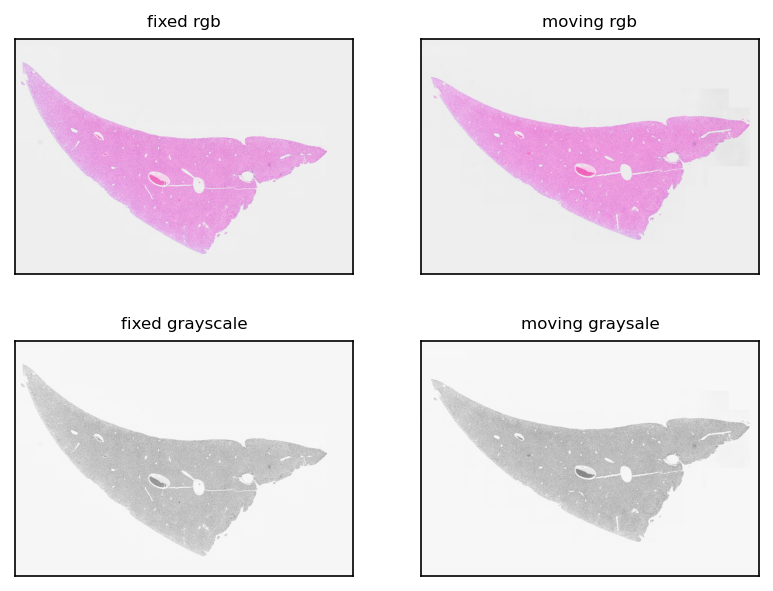

In [27]:
fig,axs=plt.subplots(2,2,dpi=150)
axs=axs.flatten()
axs[0].imshow(fixed_rgb)
axs[0].set_title("fixed rgb", fontsize=8)
axs[1].imshow(moving_rgb)
axs[1].set_title("moving rgb", fontsize=8)
axs[2].imshow(fixed_image,cmap="Grays_r")
axs[2].set_title("fixed grayscale", fontsize=8)
axs[3].imshow(moving_image,cmap="Grays_r")
axs[3].set_title("moving graysale", fontsize=8)

for ax in axs:
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

plt.plot()
plt.show()

#del fixed_rgb,moving_rgb


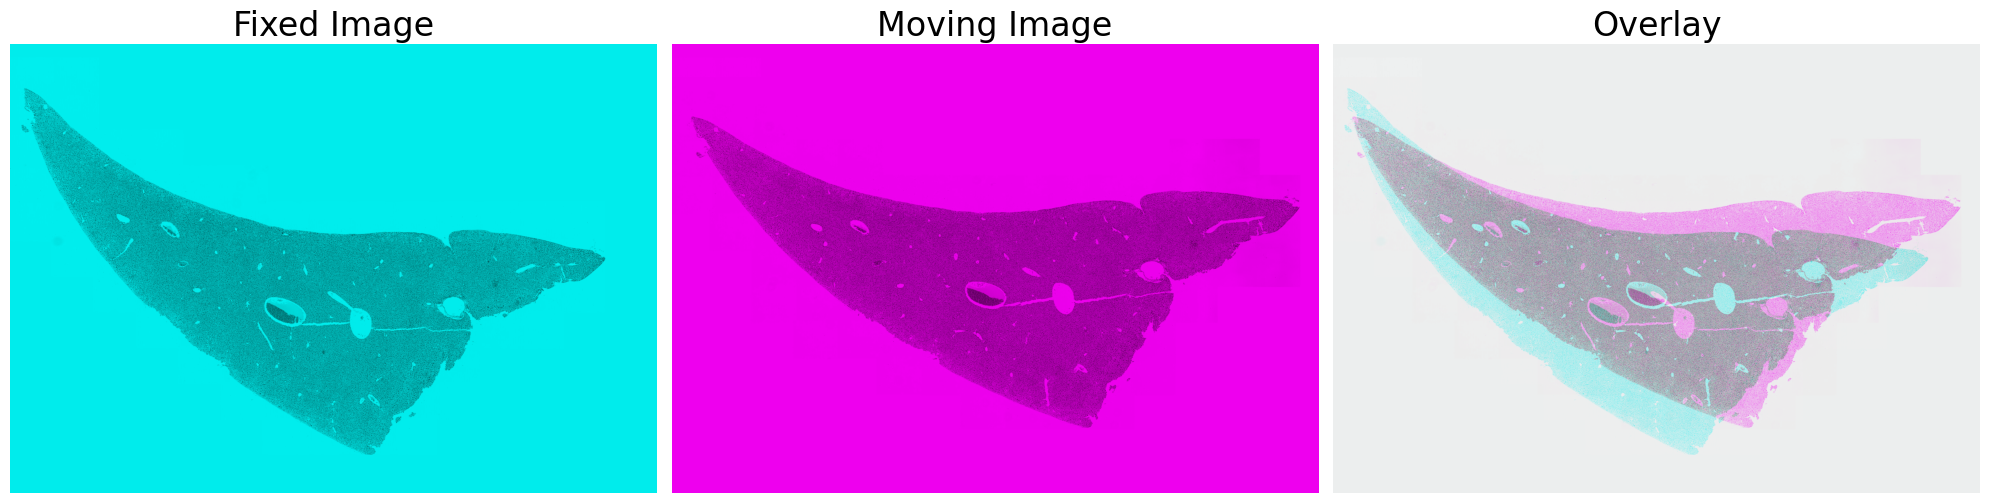

In [6]:

# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)

fixed_slice = (fixed_arr - fixed_arr.min()) / (np.ptp(fixed_arr) + 1e-8)
moving_slice = (moving_arr - moving_arr.min()) / (np.ptp(moving_arr) + 1e-8)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
fixed_color[:, :, 1] = fixed_slice
fixed_color[:, :, 2] = fixed_slice

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3))
moving_color[:, :, 0] = moving_slice
moving_color[:, :, 2] = moving_slice

before_reg = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
before_reg[:, :, 1] = moving_slice
before_reg[:, :, 0] = fixed_slice
before_reg[:, :, 2] = np.maximum(fixed_slice, moving_slice)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)
axes[0].axis('off')

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)
axes[1].axis('off')

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)
axes[2].axis('off')

plt.tight_layout()

### Registration 

We aid the registration process by doing a first rigid pass, followed by a second affine pass. 

Additionally, we give a small push to the affine step by giving it more resolutions. Five resolutions means that the affine step will create 5 downsampled versions of the image and align them all to compute a final transformation. This is necessary because our image is quite big. When transformations are expected to be large, one can push by increasing the number of resolutions, amongst other parameters.

In [7]:

rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
affine_parameter_map = itk.ParameterObject.GetDefaultParameterMap("affine")

affine_parameter_map["NumberOfResolutions"] = ["5"]

parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterMap(rigid_parameter_map)
parameter_object.AddParameterMap(affine_parameter_map)

In [8]:
# Call registration function
result_image, result_transform_parameters = itk.elastix_registration_method(
    fixed_image, moving_image, parameter_object=parameter_object, log_to_console=False
)

In [ ]:
#Saving the registered image
itk.imwrite(result_image, image_location+"RegisteredLiverTissue.tif")

### Visualization

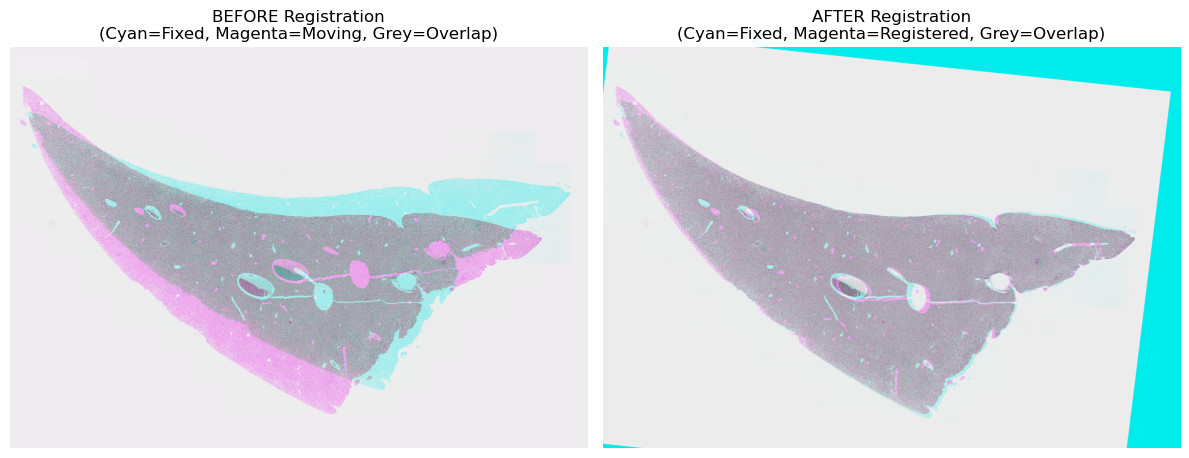

In [9]:

# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(float)
moving_arr = itk.GetArrayFromImage(moving_image).astype(float)
registered_arr = itk.GetArrayFromImage(result_image).astype(float)


fixed_slice = (fixed_arr - fixed_arr.min()) / (np.ptp(fixed_arr) + 1e-8)
moving_slice = (moving_arr - moving_arr.min()) / (np.ptp(moving_arr) + 1e-8)
registered_slice = (registered_arr - registered_arr.min()) / (np.ptp(registered_arr) + 1e-8)

# Create BEFORE overlay (Fixed vs Moving)
overlay_before = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_before[:, :, 0] = moving_slice                          # Magenta = Moving
overlay_before[:, :, 1] = fixed_slice                            # Cyan = Fixed
overlay_before[:, :, 2] = np.maximum(fixed_slice, moving_slice)  # Greyscale = Overlap

# Create AFTER overlay (Fixed vs Registered)
overlay_after = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3))
overlay_after[:, :, 0] = registered_slice                          # Magenta = Registered
overlay_after[:, :, 1] = fixed_slice                               # Cyan = Fixed
overlay_after[:, :, 2] = np.maximum(fixed_slice, registered_slice) # Greyscale = Overlap

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('BEFORE Registration\n(Cyan=Fixed, Magenta=Moving, Grey=Overlap)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('AFTER Registration\n(Cyan=Fixed, Magenta=Registered, Grey=Overlap)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Registration quality: 

Normalized Mutual Information (NMI) is a powerful similarity metric used in image registration (especially for multi-modal images, like MRI + CT scans). It measures how much information two images share, regardless of their brightness or contrast.

High NMI (close to 2.0) = The images are very similar 
Low NMI (close to 1.0) = The images are completely unrelated.

In [28]:
from skimage.metrics import normalized_mutual_information

NMI_before = normalized_mutual_information(fixed_slice, moving_slice)
NMI_after = normalized_mutual_information(fixed_slice, registered_slice)

print(NMI_before)
print(NMI_after)


1.0960793923249488
1.1619274212168589


as observed NMI is higher after registration

A default set of registration parameters are available for

* translation
* rigid
* affine
* bspline
* spline
* groupwise

### Understanding the parameters

In [29]:
# Get number of transforms (could be multiple for multi-resolution)
num_transforms = result_transform_parameters.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Get the parameter map (usually index 0 for single transform)
param_map = result_transform_parameters.GetParameterMap(0)

# Print all parameters
print("All Parameters")
for key in param_map:
    print(f"{key}: {param_map[key]}")

Number of parameter maps: 2
All Parameters
CenterOfRotationPoint: ('1013.5', '703.5')
CompressResultImage: ('false',)
DefaultPixelValue: ('0',)
Direction: ('1', '0', '0', '1')
FinalBSplineInterpolationOrder: ('3',)
FixedImageDimension: ('2',)
FixedInternalImagePixelType: ('float',)
HowToCombineTransforms: ('Compose',)
Index: ('0', '0')
InitialTransformParameterFileName: ('NoInitialTransform',)
MovingImageDimension: ('2',)
MovingInternalImagePixelType: ('float',)
NumberOfParameters: ('3',)
Origin: ('0', '0')
ResampleInterpolator: ('FinalBSplineInterpolator',)
Resampler: ('DefaultResampler',)
ResultImageFormat: ('nii',)
ResultImagePixelType: ('float32',)
Size: ('2028', '1408')
Spacing: ('1', '1')
Transform: ('EulerTransform',)
TransformParameters: ('-0.025098535866328237', '27.75338063304716', '-45.7248022414146')
UseDirectionCosines: ('true',)


### Visualizing the transformation with a grid image

Applying the resulting transform parameters to a regular grid image makes the geometric effect of the registration (translation, rotation, shearing, scaling) much easier to see than comparing the photographic images alone.

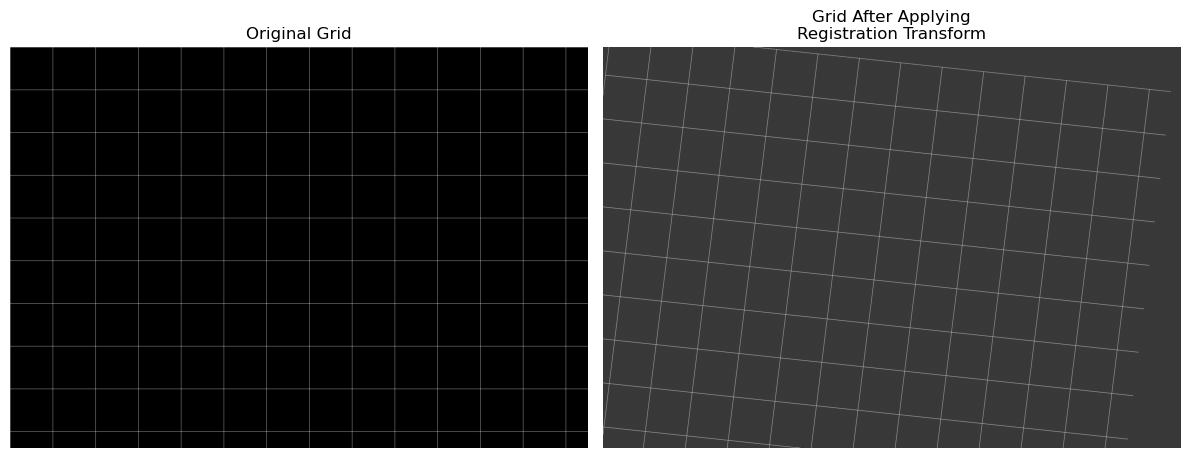

In [30]:
# Create a synthetic grid image in the moving image's space
grid_arr = np.zeros_like(moving_arr, dtype=np.float32)
grid_spacing = 150
grid_arr[::grid_spacing, :] = 1
grid_arr[:, ::grid_spacing] = 1

grid_image = itk.GetImageFromArray(grid_arr)
grid_image.CopyInformation(moving_image)

# Apply the transform found during registration to the grid image
transformed_grid = itk.transformix_filter(
    grid_image, transform_parameter_object=result_transform_parameters, log_to_console=False
)
transformed_grid_arr = itk.GetArrayFromImage(transformed_grid)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(grid_arr, cmap='gray')
axes[0].set_title('Original Grid')
axes[0].axis('off')

axes[1].imshow(transformed_grid_arr, cmap='gray')
axes[1].set_title('Grid After Applying\nRegistration Transform')
axes[1].axis('off')

plt.tight_layout()
plt.show()